<a href="https://colab.research.google.com/github/josenomberto/UTEC-CDIAV3-MCD8010/blob/main/Semana_13_gd_practica.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Práctica: Gradient Descent en Deep Learning

**Curso:** Machine Learning  
**Tema:** Descenso del Gradiente

---

### Integrantes

| # | Nombre completo |
|---|----------------|
| 1 |                |
| 2 |                |
| 3 |                |
| 4 |                |
| 5 |                |

---

## Objetivo

Implementar el algoritmo de **Descenso del Gradiente (Gradient Descent)** desde cero para entrenar una red neuronal simple (perceptrón multicapa con una capa oculta) que clasifique datos no linealmente separables.

Al finalizar esta práctica serás capaz de:
1. Comprender cómo se propagan las señales hacia adelante (*forward pass*).
2. Calcular gradientes mediante *backpropagation*.
3. Actualizar pesos usando gradient descent.
4. Visualizar la superficie de decisión y la curva de pérdida.
5. Experimentar con hiperparámetros (learning rate, épocas).

## Parte 0 — Importaciones y configuración

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

np.random.seed(42)

%matplotlib inline
plt.rcParams['figure.figsize'] = (8, 5)

## Parte 1 — Generación del dataset

Generaremos un dataset sintético con forma de **lunas (moons)** que NO es linealmente separable. Esto justifica el uso de una red neuronal con capa oculta.

X shape: (400, 2)
y shape: (400, 1)


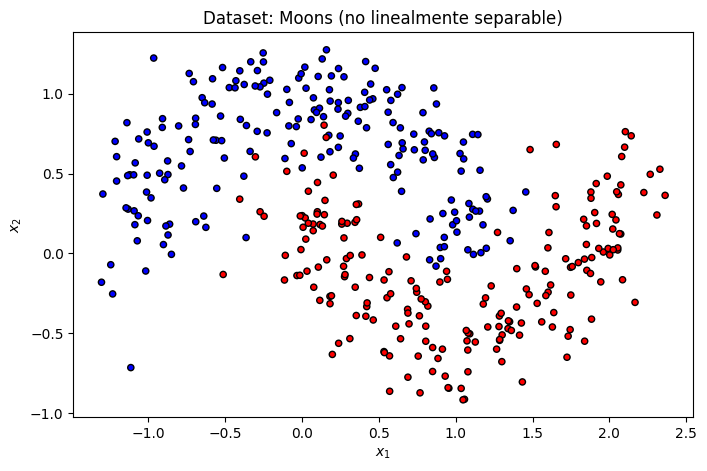

In [2]:
from sklearn.datasets import make_moons

# Generar 400 muestras con ruido
X, y = make_moons(n_samples=400, noise=0.2, random_state=42)

# Reshape de y para que sea un vector columna (400, 1)
y = y.reshape(-1, 1)

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

# Visualización
plt.scatter(X[:, 0], X[:, 1], c=y.ravel(), cmap='bwr', edgecolors='k', s=20)
plt.title('Dataset: Moons (no linealmente separable)')
plt.xlabel('$x_1$')
plt.ylabel('$x_2$')
plt.show()

## Parte 2 — Funciones de activación

### Tarea 1: Implementar la función sigmoide y su derivada

Recordar:

$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

$$\sigma'(z) = \sigma(z) \cdot (1 - \sigma(z))$$

In [3]:
def sigmoid(z):
    """Función de activación sigmoide."""
    # ============================================
    # TODO: Implementar la función sigmoide
    # ============================================

    sigmoid = 1 / (1 + np.exp(-z))
    return sigmoid


def sigmoid_derivative(z):
    """Derivada de la función sigmoide."""
    # ============================================
    # TODO: Implementar la derivada de la sigmoide
    # Hint: usa la función sigmoid() definida arriba
    # ============================================

    sigmoid_derivative = sigmoid(z) * (1 - sigmoid(z))
    return sigmoid_derivative

In [4]:
# Verificación: NO modificar esta celda
z_test = np.array([-2, -1, 0, 1, 2])
print("sigmoid([-2,-1,0,1,2]) =", sigmoid(z_test))
print("Esperado:               [0.1192 0.2689 0.5    0.7311 0.8808]")
print()
print("sigmoid_derivative([-2,-1,0,1,2]) =", sigmoid_derivative(z_test))
print("Esperado:                          [0.1050 0.1966 0.2500 0.1966 0.1050]")

sigmoid([-2,-1,0,1,2]) = [0.11920292 0.26894142 0.5        0.73105858 0.88079708]
Esperado:               [0.1192 0.2689 0.5    0.7311 0.8808]

sigmoid_derivative([-2,-1,0,1,2]) = [0.10499359 0.19661193 0.25       0.19661193 0.10499359]
Esperado:                          [0.1050 0.1966 0.2500 0.1966 0.1050]


### Tarea 2: Implementar la función ReLU y su derivada

$$\text{ReLU}(z) = \max(0, z)$$

$$\text{ReLU}'(z) = \begin{cases} 1 & \text{si } z > 0 \\ 0 & \text{si } z \leq 0 \end{cases}$$

In [5]:
def relu(z):
    """Función de activación ReLU."""
    # ============================================
    # TODO: Implementar ReLU
    # ============================================
    relu = np.maximum(0, z)
    return relu


def relu_derivative(z):
    """Derivada de la función ReLU."""
    # ============================================
    # TODO: Implementar la derivada de ReLU
    # Hint: retorna un array de 1s y 0s
    # ============================================
    relu_derivative = np.where(z > 0, 1, 0)
    return relu_derivative

In [6]:
# Verificación: NO modificar esta celda
z_test = np.array([-2, -1, 0, 1, 2])
print("relu([-2,-1,0,1,2]) =", relu(z_test))
print("Esperado:             [0 0 0 1 2]")
print()
print("relu_derivative([-2,-1,0,1,2]) =", relu_derivative(z_test))
print("Esperado:                        [0 0 0 1 1]")

relu([-2,-1,0,1,2]) = [0 0 0 1 2]
Esperado:             [0 0 0 1 2]

relu_derivative([-2,-1,0,1,2]) = [0 0 0 1 1]
Esperado:                        [0 0 0 1 1]


## Parte 3 — Arquitectura de la red neuronal

Construiremos una red con la siguiente arquitectura:

```
Entrada (2) → Capa Oculta (16 neuronas, ReLU) → Salida (1, Sigmoide)
```

### Tarea 3: Inicializar los pesos y sesgos

Los pesos deben inicializarse con valores pequeños aleatorios (distribución normal escalada) y los sesgos en cero.

In [9]:
def initialize_parameters(n_input, n_hidden, n_output):
    """
    Inicializa los parámetros de la red neuronal.

    Args:
        n_input:  número de features de entrada (2)
        n_hidden: número de neuronas en capa oculta (16)
        n_output: número de neuronas de salida (1)

    Returns:
        dict con W1, b1, W2, b2
    """
    # ============================================
    # TODO: Inicializar los pesos y sesgos
    #
    # W1: shape (n_input, n_hidden)   — pesos capa oculta
    # b1: shape (1, n_hidden)         — sesgos capa oculta
    # W2: shape (n_hidden, n_output)  — pesos capa salida
    # b2: shape (1, n_output)         — sesgos capa salida
    #
    # Hint: usa np.random.randn() * 0.5 para los pesos
    #       y np.zeros() para los sesgos
    # ============================================
    W1 = np.random.randn(n_input, n_hidden) * 0.5
    b1 = np.zeros((1, n_hidden))
    W2 = np.random.randn(n_hidden, n_output) * 0.5
    b2 = np.zeros((1, n_output))

    return {'W1': W1, 'b1': b1, 'W2': W2, 'b2': b2}

In [10]:
# Verificación: NO modificar esta celda
params = initialize_parameters(2, 16, 1)
print(f"W1 shape: {params['W1'].shape}  — esperado: (2, 16)")
print(f"b1 shape: {params['b1'].shape}  — esperado: (1, 16)")
print(f"W2 shape: {params['W2'].shape}  — esperado: (16, 1)")
print(f"b2 shape: {params['b2'].shape}  — esperado: (1, 1)")

W1 shape: (2, 16)  — esperado: (2, 16)
b1 shape: (1, 16)  — esperado: (1, 16)
W2 shape: (16, 1)  — esperado: (16, 1)
b2 shape: (1, 1)  — esperado: (1, 1)


## Parte 4 — Forward Pass

### Tarea 4: Implementar la propagación hacia adelante

El forward pass calcula:

$$z_1 = X \cdot W_1 + b_1$$
$$a_1 = \text{ReLU}(z_1)$$
$$z_2 = a_1 \cdot W_2 + b_2$$
$$\hat{y} = \sigma(z_2)$$

In [11]:
def forward(X, params):
    """
    Realiza el forward pass de la red.

    Args:
        X:      datos de entrada (n_samples, n_features)
        params: diccionario con W1, b1, W2, b2

    Returns:
        cache: dict con z1, a1, z2, a2 (necesarios para backprop)
    """
    W1, b1 = params['W1'], params['b1']
    W2, b2 = params['W2'], params['b2']

    # ============================================
    # TODO: Calcular z1, a1, z2, a2
    #
    # z1 = producto punto de X con W1, más b1
    # a1 = activación ReLU de z1
    # z2 = producto punto de a1 con W2, más b2
    # a2 = activación sigmoide de z2 (predicción)
    # ============================================
    z1 = np.dot(X, W1) + b1
    a1 = relu(z1)
    z2 = np.dot(a1, W2) + b2
    a2 = sigmoid(z2)

    cache = {'z1': z1, 'a1': a1, 'z2': z2, 'a2': a2}
    return cache

In [12]:
# Verificación: NO modificar esta celda
np.random.seed(42)
params = initialize_parameters(2, 16, 1)
cache = forward(X, params)
print(f"a2 shape: {cache['a2'].shape}  — esperado: (400, 1)")
print(f"a2 min:   {cache['a2'].min():.4f}  — debe ser > 0")
print(f"a2 max:   {cache['a2'].max():.4f}  — debe ser < 1")

a2 shape: (400, 1)  — esperado: (400, 1)
a2 min:   0.1154  — debe ser > 0
a2 max:   0.6392  — debe ser < 1


## Parte 5 — Función de costo (Binary Cross-Entropy)

### Tarea 5: Implementar la función de costo

$$\mathcal{L} = -\frac{1}{m} \sum_{i=1}^{m} \left[ y^{(i)} \log(\hat{y}^{(i)}) + (1 - y^{(i)}) \log(1 - \hat{y}^{(i)}) \right]$$

In [13]:
def compute_loss(y, y_hat):
    """
    Calcula la pérdida Binary Cross-Entropy.

    Args:
        y:     etiquetas reales (m, 1)
        y_hat: predicciones (m, 1)

    Returns:
        loss: escalar con el costo promedio
    """
    m = y.shape[0]
    epsilon = 1e-8  # para evitar log(0)

    # ============================================
    # TODO: Calcular la binary cross-entropy
    #
    # Hint: usa np.log() y recuerda el epsilon
    #       loss = -(1/m) * suma de [...]
    # ============================================
    loss = -(1/m) * np.sum(y * np.log(y_hat) + (1 - y) * np.log(1 - y_hat))

    return loss

In [14]:
# Verificación: NO modificar esta celda
np.random.seed(42)
params = initialize_parameters(2, 16, 1)
cache = forward(X, params)
loss = compute_loss(y, cache['a2'])
print(f"Loss inicial: {loss:.4f}  — debe estar cercano a 0.6931 (log(2))")

Loss inicial: 0.9931  — debe estar cercano a 0.6931 (log(2))


## Parte 6 — Backpropagation

### Tarea 6: Implementar la retropropagación

Esta es la parte central de Gradient Descent. Debemos calcular los gradientes de la función de costo respecto a cada parámetro.

Las fórmulas son:

$$dz_2 = \hat{y} - y$$
$$dW_2 = \frac{1}{m} a_1^T \cdot dz_2$$
$$db_2 = \frac{1}{m} \sum dz_2$$
$$dz_1 = dz_2 \cdot W_2^T \odot \text{ReLU}'(z_1)$$
$$dW_1 = \frac{1}{m} X^T \cdot dz_1$$
$$db_1 = \frac{1}{m} \sum dz_1$$

In [15]:
def backward(X, y, params, cache):
    """
    Calcula los gradientes mediante backpropagation.

    Args:
        X:      datos de entrada
        y:      etiquetas reales
        params: diccionario con W1, b1, W2, b2
        cache:  diccionario con z1, a1, z2, a2 del forward pass

    Returns:
        grads: dict con dW1, db1, dW2, db2
    """
    m = X.shape[0]
    W2 = params['W2']
    a1, a2, z1 = cache['a1'], cache['a2'], cache['z1']

    # ============================================
    # TODO: Calcular los gradientes
    #
    # Paso 1: dz2 = a2 - y
    # Paso 2: dW2 = (1/m) * a1^T . dz2
    # Paso 3: db2 = (1/m) * suma de dz2 (axis=0, keepdims=True)
    # Paso 4: dz1 = dz2 . W2^T * relu_derivative(z1)
    # Paso 5: dW1 = (1/m) * X^T . dz1
    # Paso 6: db1 = (1/m) * suma de dz1 (axis=0, keepdims=True)
    # ============================================
    dz2 = a2 - y
    dW2 = (1/m) * np.dot(a1.T, dz2)
    db2 = (1/m) * np.sum(dz2, axis=0, keepdims=True)
    dz1 = np.dot(dz2, W2.T) * relu_derivative(z1)
    dW1 = (1/m) * np.dot(X.T, dz1)
    db1 = (1/m) * np.sum(dz1, axis=0, keepdims=True)

    return {'dW1': dW1, 'db1': db1, 'dW2': dW2, 'db2': db2}

In [16]:
# Verificación: NO modificar esta celda
np.random.seed(42)
params = initialize_parameters(2, 16, 1)
cache = forward(X, params)
grads = backward(X, y, params, cache)
print(f"dW1 shape: {grads['dW1'].shape}  — esperado: (2, 16)")
print(f"db1 shape: {grads['db1'].shape}  — esperado: (1, 16)")
print(f"dW2 shape: {grads['dW2'].shape}  — esperado: (16, 1)")
print(f"db2 shape: {grads['db2'].shape}  — esperado: (1, 1)")

dW1 shape: (2, 16)  — esperado: (2, 16)
db1 shape: (1, 16)  — esperado: (1, 16)
dW2 shape: (16, 1)  — esperado: (16, 1)
db2 shape: (1, 1)  — esperado: (1, 1)


## Parte 7 — Actualización de parámetros (Gradient Descent)

### Tarea 7: Implementar la regla de actualización

$$\theta = \theta - \alpha \cdot \nabla_{\theta} \mathcal{L}$$

Donde $\alpha$ es el *learning rate*.

In [17]:
def update_parameters(params, grads, learning_rate):
    """
    Actualiza los parámetros usando gradient descent.

    Args:
        params:        dict con W1, b1, W2, b2
        grads:         dict con dW1, db1, dW2, db2
        learning_rate: tasa de aprendizaje (alpha)

    Returns:
        params: diccionario actualizado
    """
    # ============================================
    # TODO: Actualizar cada parámetro
    #
    # W1 = W1 - learning_rate * dW1
    # b1 = b1 - learning_rate * db1
    # W2 = W2 - learning_rate * dW2
    # b2 = b2 - learning_rate * db2
    # ============================================
    W1_updated = params['W1'] - learning_rate * grads['dW1']
    b1_updated = params['b1'] - learning_rate * grads['db1']
    W2_updated = params['W2'] - learning_rate * grads['dW2']
    b2_updated = params['b2'] - learning_rate * grads['db2']
    params_updated = {'W1': W1_updated, 'b1': b1_updated, 'W2': W2_updated, 'b2': b2_updated}

    return params_updated

## Parte 8 — Entrenamiento completo

### Tarea 8: Completar el bucle de entrenamiento

Unir todas las piezas en un ciclo de entrenamiento.

In [18]:
def train(X, y, n_hidden=16, learning_rate=0.5, epochs=1000, print_every=100):
    """
    Entrena la red neuronal completa.

    Returns:
        params:  parámetros entrenados
        losses:  lista con la pérdida en cada época
    """
    n_input = X.shape[1]
    n_output = 1
    losses = []

    # Paso 1: Inicializar parámetros
    params = initialize_parameters(n_input, n_hidden, n_output)

    for epoch in range(epochs):
        # ============================================
        # TODO: Completar el bucle de entrenamiento
        #
        # Paso 2: Forward pass
        # Paso 3: Calcular la pérdida
        # Paso 4: Backward pass (calcular gradientes)
        # Paso 5: Actualizar parámetros
        # ============================================

        params = initialize_parameters(2, 16, 1)
        cache = forward(X, params)
        loss = compute_loss(y, cache['a2'])
        grads = backward(X, y, params, cache)
        params = update_parameters(params,grads,learning_rate)

        # Registrar pérdida (descomentar cuando completes los pasos)
        losses.append(loss)
        if epoch % print_every == 0:
            print(f"Época {epoch:4d} | Loss: {loss:.4f}")

    return params, losses

In [19]:
# Entrenar la red
np.random.seed(42)
trained_params, losses = train(X, y, n_hidden=16, learning_rate=0.5, epochs=2000, print_every=200)

Época    0 | Loss: 0.6845
Época  200 | Loss: 0.6428
Época  400 | Loss: 0.7941
Época  600 | Loss: 0.8282
Época  800 | Loss: 0.7463
Época 1000 | Loss: 0.6527
Época 1200 | Loss: 0.9706
Época 1400 | Loss: 0.9474
Época 1600 | Loss: 0.7818
Época 1800 | Loss: 0.6741


## Parte 9 — Visualización de resultados

In [ ]:
# 9a. Curva de pérdida
plt.plot(losses)
plt.title('Curva de Pérdida durante el Entrenamiento')
plt.xlabel('Época')
plt.ylabel('Binary Cross-Entropy Loss')
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
# 9b. Precisión del modelo
cache = forward(X, trained_params)
predictions = (cache['a2'] > 0.5).astype(int)
accuracy = np.mean(predictions == y) * 100
print(f"Precisión del modelo: {accuracy:.2f}%")

In [ ]:
# 9c. Superficie de decisión
def plot_decision_boundary(X, y, params):
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                         np.arange(y_min, y_max, 0.02))
    grid = np.c_[xx.ravel(), yy.ravel()]

    cache = forward(grid, params)
    Z = (cache['a2'] > 0.5).astype(int).reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.3, cmap='bwr')
    plt.scatter(X[:, 0], X[:, 1], c=y.ravel(), cmap='bwr', edgecolors='k', s=20)
    plt.title('Superficie de Decisión')
    plt.xlabel('$x_1$')
    plt.ylabel('$x_2$')
    plt.show()

plot_decision_boundary(X, y, trained_params)

## Parte 10 — Experimentación con hiperparámetros

### Tarea 9: Experimentar con diferentes learning rates

Entrena el modelo con los siguientes learning rates y compara las curvas de pérdida: `[0.01, 0.1, 0.5, 2.0]`

In [ ]:
learning_rates = [0.01, 0.1, 0.5, 2.0]

plt.figure(figsize=(10, 6))

for lr in learning_rates:
    np.random.seed(42)
    # ============================================
    # TODO: Entrenar el modelo con cada learning rate
    # y graficar la curva de pérdida
    #
    # _, losses_lr = train(X, y, ...)
    # plt.plot(losses_lr, label=f'lr={lr}')
    # ============================================
    pass

plt.title('Comparación de Learning Rates')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Tarea 10: Experimentar con diferentes tamaños de capa oculta

Entrena el modelo con capas ocultas de tamaño: `[2, 4, 16, 64]` y visualiza las superficies de decisión.

In [ ]:
hidden_sizes = [2, 4, 16, 64]

fig, axes = plt.subplots(1, 4, figsize=(20, 4))

for i, n_h in enumerate(hidden_sizes):
    np.random.seed(42)
    # ============================================
    # TODO: Entrenar el modelo con cada tamaño de capa oculta
    # y graficar la superficie de decisión en axes[i]
    #
    # Hint: adapta plot_decision_boundary para usar axes[i]
    # ============================================
    pass

plt.tight_layout()
plt.show()

---

## Conclusiones

Responde las siguientes preguntas basándote en tus resultados experimentales:

### Pregunta 1
¿Qué sucede cuando el learning rate es demasiado pequeño? ¿Y cuando es demasiado grande?

*Tu respuesta aquí:*



### Pregunta 2
¿Cómo afecta el número de neuronas en la capa oculta a la capacidad del modelo para aprender la frontera de decisión?

*Tu respuesta aquí:*



### Pregunta 3
¿Por qué es necesario usar una función de activación no lineal (como ReLU) en la capa oculta? ¿Qué pasaría si usáramos solo funciones lineales?

*Tu respuesta aquí:*



### Pregunta 4
¿Cuál es el rol del gradiente en el proceso de entrenamiento? Explica con tus propias palabras cómo backpropagation permite que la red "aprenda".

*Tu respuesta aquí:*

